In [1]:
# Importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print("Libraries loaded successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully!


In [4]:
# Loading the dataset
df = pd.read_csv('../data/raw/MUP_INP_RY25_P03_V10_DY23_PrvSvc.CSV', encoding='latin-1')

# First look
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")

Shape: (146427, 15)

Columns:
['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_St', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'DRG_Cd', 'DRG_Desc', 'Tot_Dschrgs', 'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt', 'Avg_Mdcr_Pymt_Amt']


In [5]:
# Basic exploration
print("=== FIRST 5 ROWS ===")
display(df.head())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
display(df[['Tot_Dschrgs', 'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt', 'Avg_Mdcr_Pymt_Amt']].describe())

=== FIRST 5 ROWS ===


,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_St,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,DRG_Cd,DRG_Desc,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt
0,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,14,"663,764.36","120,219.93","115,544.14"
1,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,26,"180,980.88","37,321.04","35,261.81"
2,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,24,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,12,"105,824.33","26,936.67","25,048.92"
3,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,25,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,16,"242,539.50","34,745.38","32,438.62"
4,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,38,EXTRACRANIAL PROCEDURES WITH CC,11,"122,741.18","14,999.82","9,579.36"



=== DATA TYPES ===
Rndrng_Prvdr_CCN               int64
Rndrng_Prvdr_Org_Name            str
Rndrng_Prvdr_City                str
Rndrng_Prvdr_St                  str
Rndrng_Prvdr_State_FIPS        int64
Rndrng_Prvdr_Zip5              int64
Rndrng_Prvdr_State_Abrvtn        str
Rndrng_Prvdr_RUCA            float64
Rndrng_Prvdr_RUCA_Desc           str
DRG_Cd                         int64
DRG_Desc                         str
Tot_Dschrgs                    int64
Avg_Submtd_Cvrd_Chrg         float64
Avg_Tot_Pymt_Amt             float64
Avg_Mdcr_Pymt_Amt            float64
dtype: object

=== MISSING VALUES ===
Rndrng_Prvdr_CCN             0
Rndrng_Prvdr_Org_Name        0
Rndrng_Prvdr_City            0
Rndrng_Prvdr_St              0
Rndrng_Prvdr_State_FIPS      0
Rndrng_Prvdr_Zip5            0
Rndrng_Prvdr_State_Abrvtn    0
Rndrng_Prvdr_RUCA            4
Rndrng_Prvdr_RUCA_Desc       4
DRG_Cd                       0
DRG_Desc                     0
Tot_Dschrgs                  0
Avg_Submtd_Cvrd

,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt
count,"146,427.00","146,427.00","146,427.00","146,427.00"
mean,33.88,"90,794.23","18,512.96","15,331.36"
std,49.81,"120,034.82","21,313.20","18,594.05"
min,11.00,"3,368.50","1,938.43",180.29
25%,14.00,"35,262.98","8,685.92","6,794.31"
50%,20.00,"58,668.57","12,830.71","10,548.18"
75%,35.00,"104,216.70","20,403.22","16,814.95"
max,"3,210.00","10,418,932.78","761,738.78","751,479.04"


In [6]:
# Creating gap column: difference between charged and paid
df['Gap_Charge_vs_Payment'] = df['Avg_Submtd_Cvrd_Chrg'] - df['Avg_Tot_Pymt_Amt']
df['Gap_Pct'] = (df['Gap_Charge_vs_Payment'] / df['Avg_Submtd_Cvrd_Chrg']) * 100

# Top 10 most expensive procedures by average charge
print("=== TOP 10 MOST EXPENSIVE PROCEDURES ===")
top_procedures = (df.groupby('DRG_Desc')['Avg_Submtd_Cvrd_Chrg']
                  .mean()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index())

top_procedures.columns = ['Procedure', 'Avg_Charge']
display(top_procedures)

=== TOP 10 MOST EXPENSIVE PROCEDURES ===


,Procedure,Avg_Charge
0,CHIMERIC ANTIGEN RECEPTOR (CAR) T-CELL AND OTH...,"2,028,203.59"
1,HEART TRANSPLANT OR IMPLANT OF HEART ASSIST SY...,"1,541,711.89"
2,LUNG TRANSPLANT,"1,101,329.09"
3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,"993,548.98"
4,LIVER TRANSPLANT WITH MCC OR INTESTINAL TRANSP...,"807,281.86"
5,TRACHEOSTOMY WITH MV >96 HOURS OR PRINCIPAL DI...,"611,926.66"
6,ALLOGENEIC BONE MARROW TRANSPLANT,"588,021.92"
7,OTHER HEART ASSIST SYSTEM IMPLANT,"510,909.46"
8,OTHER HEPATOBILIARY OR PANCREAS O.R. PROCEDURE...,"508,914.48"
9,COMBINED ANTERIOR AND POSTERIOR SPINAL FUSION ...,"495,647.55"


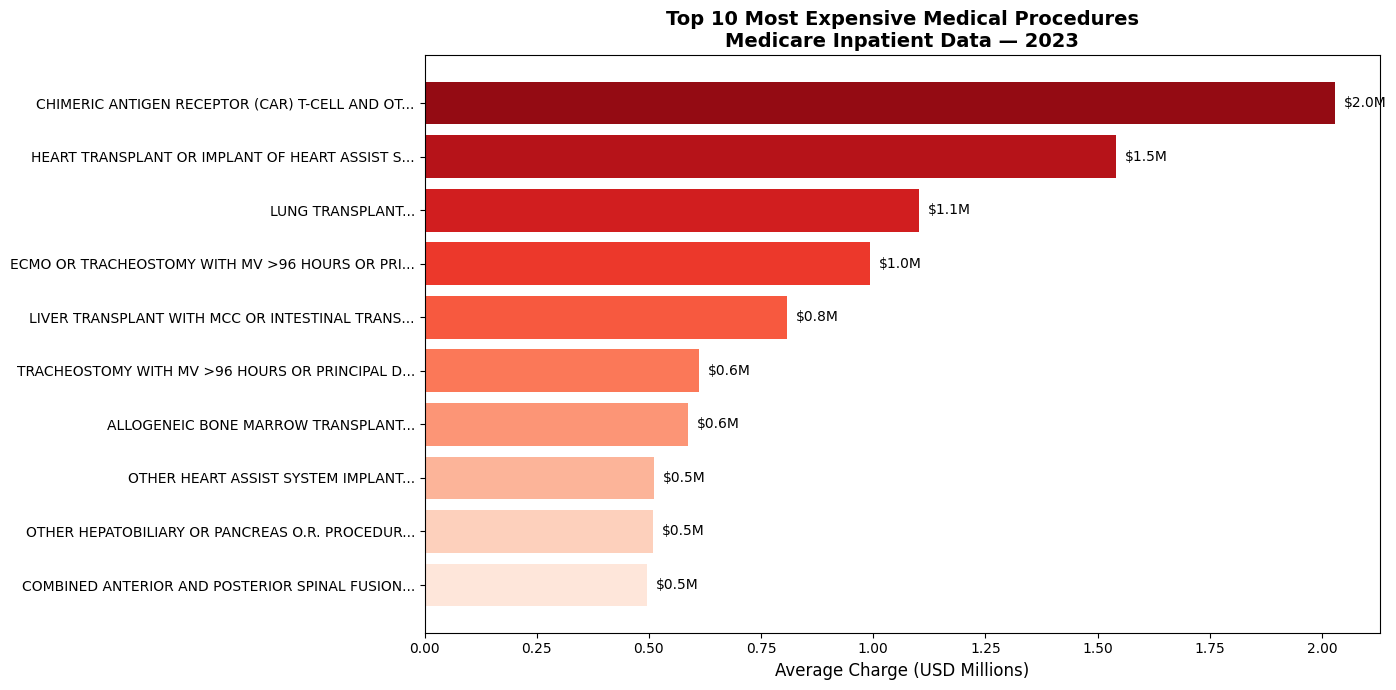

Chart saved!


In [7]:
# Top 10 most expensive procedures - Bar Chart
plt.figure(figsize=(14, 7))

# Shortening procedure names for visualization
top_procedures['Short_Name'] = top_procedures['Procedure'].str[:45] + '...'

bars = plt.barh(top_procedures['Short_Name'], 
                top_procedures['Avg_Charge'] / 1_000_000,
                color=sns.color_palette("Reds_r", 10))

plt.xlabel('Average Charge (USD Millions)', fontsize=12)
plt.title('Top 10 Most Expensive Medical Procedures\nMedicare Inpatient Data — 2023', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()

# Adding value labels on bars
for bar, val in zip(bars, top_procedures['Avg_Charge'] / 1_000_000):
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'${val:.1f}M', va='center', fontsize=10)

plt.savefig('../docs/top10_expensive_procedures.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [8]:
# Average charges and payments by state
state_analysis = (df.groupby('Rndrng_Prvdr_State_Abrvtn')
                  .agg(
                      Avg_Charge=('Avg_Submtd_Cvrd_Chrg', 'mean'),
                      Avg_Payment=('Avg_Tot_Pymt_Amt', 'mean'),
                      Avg_Medicare=('Avg_Mdcr_Pymt_Amt', 'mean'),
                      Total_Discharges=('Tot_Dschrgs', 'sum')
                  )
                  .sort_values('Avg_Charge', ascending=False)
                  .reset_index())

state_analysis.columns = ['State', 'Avg_Charge', 'Avg_Payment', 'Avg_Medicare', 'Total_Discharges']

print("=== TOP 10 MOST EXPENSIVE STATES ===")
display(state_analysis.head(10))

=== TOP 10 MOST EXPENSIVE STATES ===


,State,Avg_Charge,Avg_Payment,Avg_Medicare,Total_Discharges
0,NV,"157,565.70","17,855.85","14,973.75",43038
1,CA,"151,711.98","24,418.15","21,041.33",441929
2,AK,"136,937.21","25,169.91","20,886.43",9387
3,CO,"133,354.58","19,183.53","16,087.46",46569
4,DC,"132,534.80","31,060.18","23,405.16",16246
5,NJ,"117,572.26","18,985.50","15,458.92",172827
6,TX,"114,009.40","18,197.01","14,917.28",332232
7,FL,"111,195.17","15,323.71","12,768.14",442286
8,NY,"106,164.57","23,488.48","19,382.19",329669
9,AZ,"101,199.99","18,373.92","15,329.93",93809


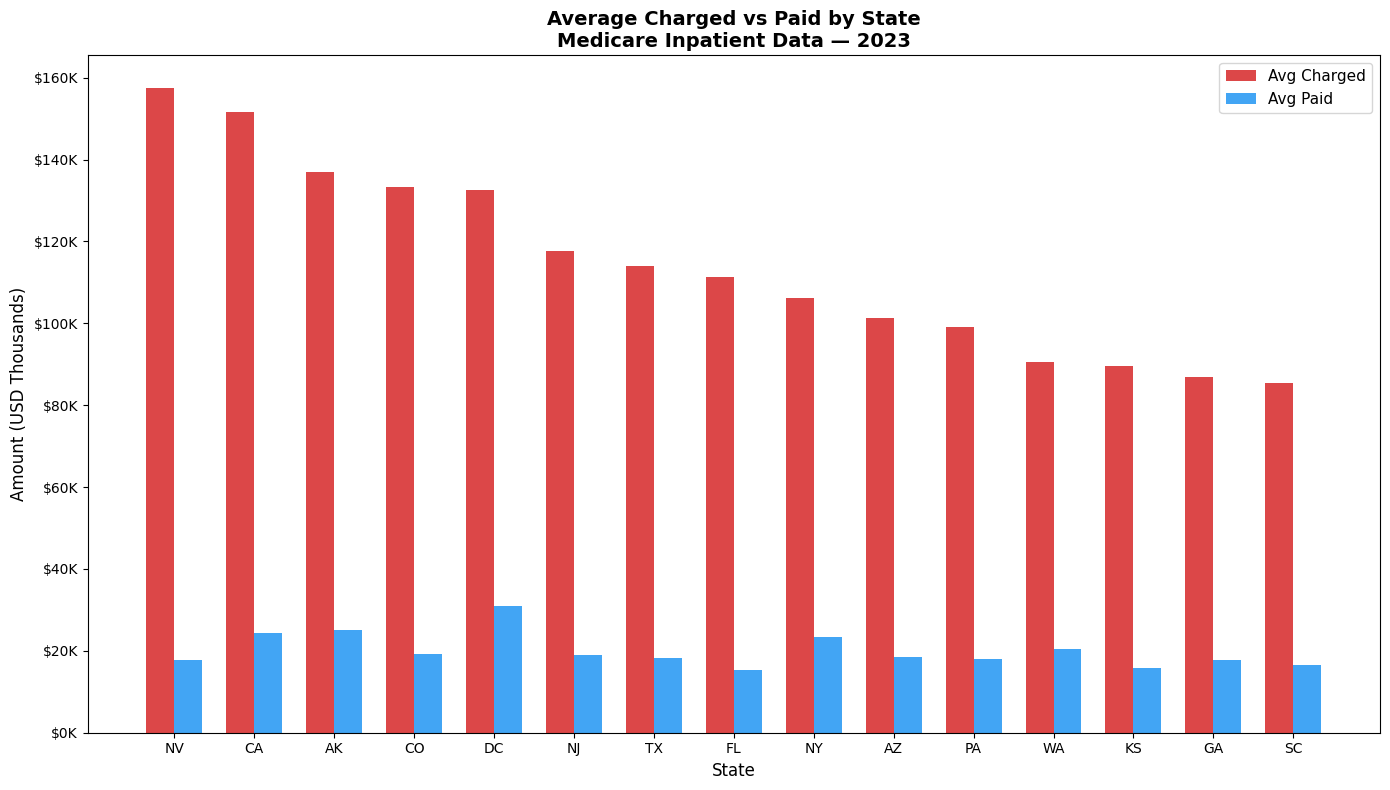

Chart saved!


In [9]:
# Top 15 states - Charge vs Payment comparison
top_states = state_analysis.head(15)

fig, ax = plt.subplots(figsize=(14, 8))

x = range(len(top_states))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], 
               top_states['Avg_Charge'] / 1_000, 
               width, label='Avg Charged', color='#d62728', alpha=0.85)

bars2 = ax.bar([i + width/2 for i in x], 
               top_states['Avg_Payment'] / 1_000, 
               width, label='Avg Paid', color='#2196F3', alpha=0.85)

ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Amount (USD Thousands)', fontsize=12)
ax.set_title('Average Charged vs Paid by State\nMedicare Inpatient Data — 2023', 
             fontsize=14, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels(top_states['State'], fontsize=10)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'${val:,.0f}K'))

plt.tight_layout()
plt.savefig('../docs/state_charge_vs_payment.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [10]:
# Hospitals with biggest gap between charged and paid
gap_analysis = (df.groupby(['Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_State_Abrvtn'])
                .agg(
                    Avg_Charge=('Avg_Submtd_Cvrd_Chrg', 'mean'),
                    Avg_Payment=('Avg_Tot_Pymt_Amt', 'mean'),
                    Total_Discharges=('Tot_Dschrgs', 'sum')
                )
                .reset_index())

gap_analysis['Gap_Pct'] = ((gap_analysis['Avg_Charge'] - gap_analysis['Avg_Payment']) 
                            / gap_analysis['Avg_Charge'] * 100)

# Filter hospitals with meaningful volume (min 100 discharges)
gap_filtered = gap_analysis[gap_analysis['Total_Discharges'] >= 100]

top_gap = gap_filtered.sort_values('Gap_Pct', ascending=False).head(10).reset_index(drop=True)

print("=== TOP 10 HOSPITALS WITH HIGHEST CHARGE INFLATION ===")
display(top_gap[['Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_State_Abrvtn', 
                  'Avg_Charge', 'Avg_Payment', 'Gap_Pct']])

=== TOP 10 HOSPITALS WITH HIGHEST CHARGE INFLATION ===


,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_State_Abrvtn,Avg_Charge,Avg_Payment,Gap_Pct
0,Capital Health Medical Center - Hopewell,NJ,"342,931.70","15,466.64",95.49
1,Capital Health Regional Medical Center,NJ,"388,014.83","19,333.71",95.02
2,Carepoint Health-Christ Hospital,NJ,"414,502.61","21,917.25",94.71
3,Carepoint Health - Bayonne Medical Center,NJ,"269,356.68","16,484.56",93.88
4,Gadsden Regional Medical Center,AL,"155,292.50","9,847.01",93.66
5,Western Arizona Regional Medical Center,AZ,"168,738.71","10,737.42",93.64
6,Summerlin Hospital Medical Center,NV,"206,522.11","13,283.62",93.57
7,Centennial Hills Hospital Medical Center,NV,"197,326.21","13,083.46",93.37
8,Hca Florida Pasadena Hospital,FL,"135,879.61","9,062.34",93.33
9,Hca Florida Fawcett Hospital,FL,"190,123.57","12,951.63",93.19


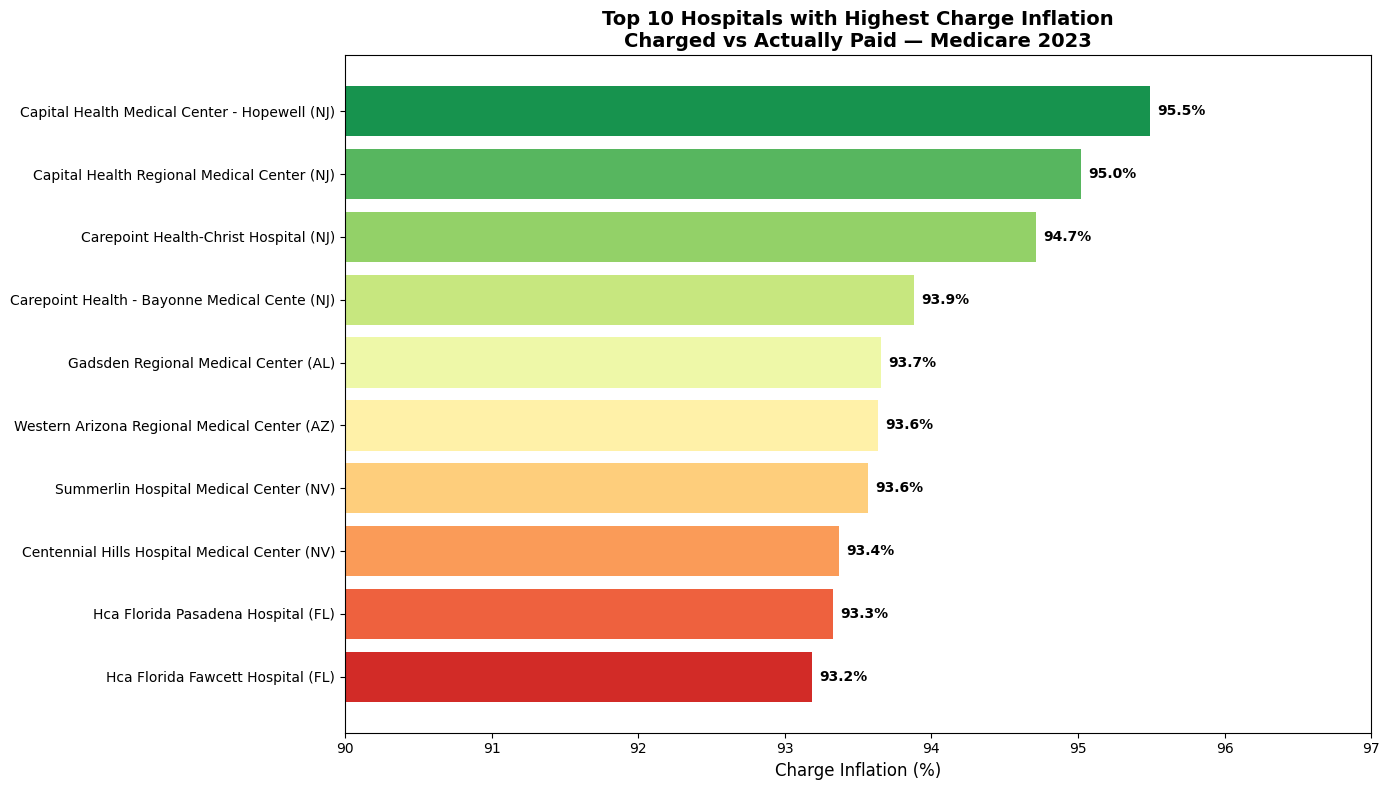

Chart saved!


In [11]:
# Hospital charge inflation chart
fig, ax = plt.subplots(figsize=(14, 8))

colors = sns.color_palette("RdYlGn_r", len(top_gap))

bars = ax.barh(
    top_gap['Rndrng_Prvdr_Org_Name'].str[:40] + ' (' + top_gap['Rndrng_Prvdr_State_Abrvtn'] + ')',
    top_gap['Gap_Pct'],
    color=colors
)

ax.set_xlabel('Charge Inflation (%)', fontsize=12)
ax.set_title('Top 10 Hospitals with Highest Charge Inflation\nCharged vs Actually Paid — Medicare 2023',
             fontsize=14, fontweight='bold')
ax.set_xlim(90, 97)
ax.gca().invert_yaxis() if hasattr(ax, 'gca') else plt.gca().invert_yaxis()

for bar, val in zip(bars, top_gap['Gap_Pct']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/hospital_charge_inflation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

## ⚠️ Analytical Note: Understanding the Pricing Gap

The charge inflation figures above require important context. 

The US healthcare system uses a **"chargemaster" pricing model** — hospitals set 
internal list prices that serve as negotiation anchors. No payer (Medicare, Medicaid, 
or private insurance) ever pays the full chargemaster rate.

**Two competing explanations exist for the gap observed:**
1. **Hospitals inflate bills** beyond reasonable cost as a negotiation strategy
2. **Medicare underpays** based on fixed DRG reimbursement rates that may not 
reflect actual care costs

**What this dataset cannot tell us:**
- Actual cost of care per procedure (staff, equipment, medication)
- Whether Medicare reimbursement rates are fair relative to true costs
- Hospital profitability per procedure

**Conclusion:** This analysis highlights a **structural pricing misalignment** in the 
US Medicare system. A complete fairness assessment would require cost-of-care data 
beyond what is publicly available in this dataset.

In [12]:
# Most common procedures by volume and their total cost impact
volume_analysis = (df.groupby('DRG_Desc')
                   .agg(
                       Total_Discharges=('Tot_Dschrgs', 'sum'),
                       Avg_Charge=('Avg_Submtd_Cvrd_Chrg', 'mean'),
                       Avg_Payment=('Avg_Tot_Pymt_Amt', 'mean')
                   )
                   .reset_index())

# Total estimated cost to Medicare
volume_analysis['Total_Medicare_Cost'] = (volume_analysis['Total_Discharges'] * 
                                           volume_analysis['Avg_Payment'])

# Top 10 by volume
top_volume = volume_analysis.sort_values('Total_Discharges', ascending=False).head(10)

print("=== TOP 10 PROCEDURES BY VOLUME ===")
display(top_volume[['DRG_Desc', 'Total_Discharges', 'Avg_Payment', 'Total_Medicare_Cost']])

=== TOP 10 PROCEDURES BY VOLUME ===


,DRG_Desc,Total_Discharges,Avg_Payment,Total_Medicare_Cost
449,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,561795,"17,235.46","9,682,794,044.65"
176,HEART FAILURE AND SHOCK WITH MCC,319702,"11,548.46","3,692,066,770.30"
434,RESPIRATORY INFECTIONS AND INFLAMMATIONS WITH MCC,166662,"15,986.29","2,664,306,616.00"
458,SIMPLE PNEUMONIA AND PLEURISY WITH MCC,125793,"11,526.67","1,449,974,349.40"
450,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,104379,"9,522.15","993,912,626.71"
422,PULMONARY EDEMA AND RESPIRATORY FAILURE,90117,"11,421.02","1,029,228,369.87"
146,"ESOPHAGITIS, GASTROENTERITIS AND MISCELLANEOUS...",86037,"7,499.89","645,267,912.60"
217,KIDNEY AND URINARY TRACT INFECTIONS WITHOUT MCC,85997,"7,480.78","643,324,361.20"
5,"ACUTE MYOCARDIAL INFARCTION, DISCHARGED ALIVE ...",83150,"14,240.94","1,184,134,305.81"
166,GASTROINTESTINAL HEMORRHAGE WITH CC,78557,"8,924.72","701,099,118.18"


In [13]:
# Check full names of duplicated septicemia procedures
septicemia = volume_analysis[volume_analysis['DRG_Desc'].str.contains('SEPTICEMIA')]
print(septicemia[['DRG_Desc', 'Total_Discharges']].to_string())

                                                         DRG_Desc  Total_Discharges
448                 SEPTICEMIA OR SEVERE SEPSIS WITH MV >96 HOURS             21332
449     SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITH MCC            561795
450  SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITHOUT MCC            104379


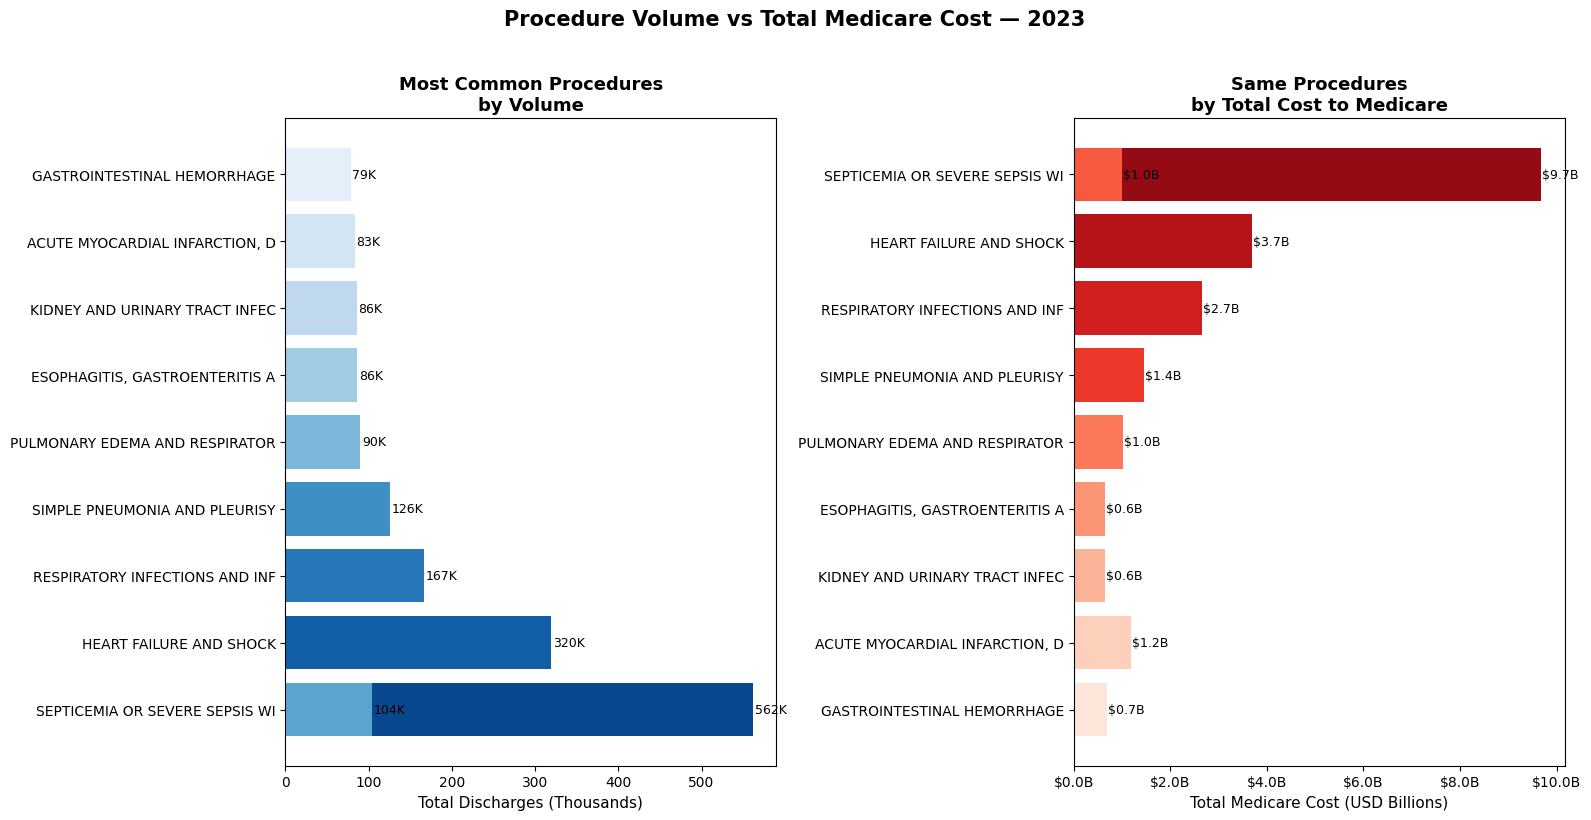

Chart saved!


In [15]:
# Cleaner version: two side-by-side bar charts
top_volume_clean['Short_Name'] = (top_volume_clean['DRG_Desc']
                                   .str.split(' WITH ').str[0]
                                   .str[:30])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Chart 1: Total Discharges
bars1 = ax1.barh(top_volume_clean['Short_Name'],
                  top_volume_clean['Total_Discharges'] / 1_000,
                  color=sns.color_palette("Blues_r", 10))
ax1.set_xlabel('Total Discharges (Thousands)', fontsize=11)
ax1.set_title('Most Common Procedures\nby Volume', fontsize=13, fontweight='bold')
ax1.gca().invert_yaxis() if hasattr(ax1, 'gca') else ax1.invert_yaxis()
ax1.invert_yaxis()
for bar, val in zip(bars1, top_volume_clean['Total_Discharges'] / 1_000):
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}K', va='center', fontsize=9)

# Chart 2: Total Medicare Cost
bars2 = ax2.barh(top_volume_clean['Short_Name'],
                  top_volume_clean['Total_Medicare_Cost'] / 1_000_000_000,
                  color=sns.color_palette("Reds_r", 10))
ax2.set_xlabel('Total Medicare Cost (USD Billions)', fontsize=11)
ax2.set_title('Same Procedures\nby Total Cost to Medicare', fontsize=13, fontweight='bold')
ax2.invert_yaxis()
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'${val:.1f}B'))
for bar, val in zip(bars2, top_volume_clean['Total_Medicare_Cost'] / 1_000_000_000):
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'${val:.1f}B', va='center', fontsize=9)

plt.suptitle('Procedure Volume vs Total Medicare Cost — 2023',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/volume_vs_cost_bars.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [16]:
import sqlalchemy as sa

# Creating SQLite database from our dataframe
engine = sa.create_engine('sqlite:///../data/processed/medicare.db')

df.to_sql('medicare_claims', engine, if_exists='replace', index=False)

print(f"Database created successfully!")
print(f"Table 'medicare_claims' with {len(df)} rows loaded.")

Database created successfully!
Table 'medicare_claims' with 146427 rows loaded.
